In [42]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit import ClassicalRegister
from qiskit.circuit.library import LinearAmplitudeFunction

from qiskit_aer.primitives import Sampler
from qiskit_finance.circuit.library import LogNormalDistribution
from qiskit_algorithms import IterativeAmplitudeEstimation, EstimationProblem

from mpl_toolkits.mplot3d import Axes3D 
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [43]:
DEFAULT_NUM_UNCERTAINTY_QUBITS = 6


def build_uncertainty_model(num_uncertainty_qubits, S0, vol, r, T):
    mu = np.log(S0) + (r - 0.5 * vol**2) * T
    sigma = vol * np.sqrt(T)
    mean = np.exp(mu + 0.5 * sigma**2)
    var = (np.exp(sigma**2) - 1.0) * np.exp(2.0 * mu + sigma**2)
    std = np.sqrt(var)
    low = max(0.0, mean - 3.0 * std)
    high = mean + 3.0 * std
    uncertainty_model = LogNormalDistribution(
        num_uncertainty_qubits,
        mu=mu,
        sigma=sigma**2,   
        bounds=(low, high),
    )
    return uncertainty_model, low, high


$$
[\text{low}, \text{high}] =
\left[
\max\!\bigl(0,\ \mathbb{E}[S_T] - 3\,\mathrm{Std}(S_T)\bigr),\ 
\mathbb{E}[S_T] + 3\,\mathrm{Std}(S_T)
\right].
$$

This is a heuristic to capture most of the probability mass.

In [44]:
def build_call_circuit(
    num_uncertainty_qubits,
    uncertainty_model,
    low,
    high,
    K,
    c_approx=0.25,
):
    K_eff = float(np.clip(K, low + 1e-9, high - 1e-9))

    f_min = 0.0
    f_max = max(0.0, high - K_eff)

    objective = LinearAmplitudeFunction(
        num_state_qubits=num_uncertainty_qubits,
        slope=[0.0, 1.0],
        offset=[0.0, 0.0],
        domain=(low, high),
        image=(f_min, f_max),
        breakpoints=[low, K_eff],
        rescaling_factor=c_approx,
    )
    european_call = QuantumCircuit(objective.num_qubits)
    european_call.append(uncertainty_model, range(num_uncertainty_qubits))
    european_call.append(objective, range(objective.num_qubits))

    objective_qubit = num_uncertainty_qubits
    return european_call, objective, objective_qubit, K_eff

This routine builds the quantum circuit that prepares the discretized distribution of $S_T$ and encodes the European call payoff $(S_T-K)^{+}$ into the amplitude of an objective qubit.

In [45]:
def exact_call_value(uncertainty_model, K):
    x = uncertainty_model.values
    probs = uncertainty_model.probabilities
    payoff = np.maximum(0.0, x - K)
    return float(np.dot(probs, payoff))


$\sum_i p_i \max(x_i-K,0)$.

In [46]:
def estimate_by_sampling(circuit, objective, objective_qubit, shots=50_000, seed=75):
    qc = circuit.copy()
    c = ClassicalRegister(1, "c")
    qc.add_register(c)
    qc.measure(objective_qubit, c[0])

    sampler = Sampler(run_options={"shots": shots, "seed": seed})
    result = sampler.run([qc]).result()
    quasi_dist = result.quasi_dists[0]
    p1_hat = float(quasi_dist.get(1, 0.0))

    payoff_estimate = float(objective.post_processing(p1_hat))
    return payoff_estimate, p1_hat


Sampling Method


This function estimates the payoff by repeatedly measuring the objective qubit, extracting the empirical probability $\hat p_1$, and mapping it back to the payoff through post-processing.

In [ ]:
def price_european_call_quantum(K, T, S0=100.0, vol=0.4, r=0.05,
                                num_uncertainty_qubits=DEFAULT_NUM_UNCERTAINTY_QUBITS,
                                c_approx=0.25, method="sampling", discount=True,
                                sampling_shots=50_000, seed=75):

    uncertainty_model, low, high = build_uncertainty_model(
        num_uncertainty_qubits, S0, vol, r, T
    )

    circuit, objective, objective_qubit, K_eff = build_call_circuit(
        num_uncertainty_qubits, uncertainty_model, low, high, K, c_approx
    )

    exact_value = exact_call_value(uncertainty_model, K_eff)

    if method == "sampling":
        est_value, p1_hat = estimate_by_sampling(
            circuit, objective, objective_qubit, shots=sampling_shots, seed=seed
        )
        extra = {"p1_hat": p1_hat}
    else:
        raise ValueError("Méthode invalide, utilisez 'sampling' ou 'iae'.")

    if discount:
        disc = np.exp(-r * T)
        exact_value *= disc
        est_value *= disc

    return {
        "K": float(K),
        "T": float(T),
        "K_eff": K_eff,
        "exact_value": float(exact_value),
        "estimate": float(est_value),
        "error": float(est_value - exact_value),
        "method": method,
        "num_uncertainty_qubits": num_uncertainty_qubits,
        "c_approx": c_approx,
        "extra": extra,
        "circuit": circuit,
        "objective_qubit": objective_qubit,
    }


In [48]:
def compute_surface(
    Ks, Ts, method="sampling", S0=100.0, vol=0.4, r=0.05,
    num_uncertainty_qubits=DEFAULT_NUM_UNCERTAINTY_QUBITS,
    c_approx=0.25, discount=True,
    sampling_shots=50_000, seed=75
):
    exact = np.zeros((len(Ts), len(Ks)))
    est = np.zeros((len(Ts), len(Ks)))
    err = np.zeros((len(Ts), len(Ks)))

    for iT, T in enumerate(Ts):
        for iK, K in enumerate(Ks):
            res = price_european_call_quantum(
                K=K,
                T=T,
                S0=S0,
                vol=vol,
                r=r,
                num_uncertainty_qubits=num_uncertainty_qubits,
                c_approx=c_approx,
                method=method,
                discount=discount,
                sampling_shots=sampling_shots,
                seed=seed,
            )
            exact[iT, iK] = res["exact_value"]
            est[iT, iK] = res["estimate"]
            err[iT, iK] = res["error"]

    return exact, est, err


def plot_3_surfaces(Ks, Ts, exact, est, err, title_suffix=""):
    K_grid, T_grid = np.meshgrid(Ks, Ts)
    fig = plt.figure(figsize=(18, 5))

    ax1 = fig.add_subplot(131, projection="3d")
    ax1.plot_surface(K_grid, T_grid, exact, linewidth=0, antialiased=True)
    ax1.set_title(f"Prix exact {title_suffix}")
    ax1.set_xlabel("Strike K")
    ax1.set_ylabel("Maturité T")
    ax1.set_zlabel("Prix")

    ax2 = fig.add_subplot(132, projection="3d")
    ax2.plot_surface(K_grid, T_grid, est, linewidth=0, antialiased=True)
    ax2.set_title(f"Prix estimé {title_suffix}")
    ax2.set_xlabel("Strike K")
    ax2.set_ylabel("Maturité T")
    ax2.set_zlabel("Prix")

    ax3 = fig.add_subplot(133, projection="3d")
    ax3.plot_surface(K_grid, T_grid, err, linewidth=0, antialiased=True)
    ax3.set_title(f"Erreur signée {title_suffix}")
    ax3.set_xlabel("Strike K")
    ax3.set_ylabel("Maturité T")
    ax3.set_zlabel("Erreur")

    plt.tight_layout()
    return fig


Single price with sampling 
Exact: 5.3650130323132235
Estimate: 6.048373354254891
Error: 0.6833603219416675


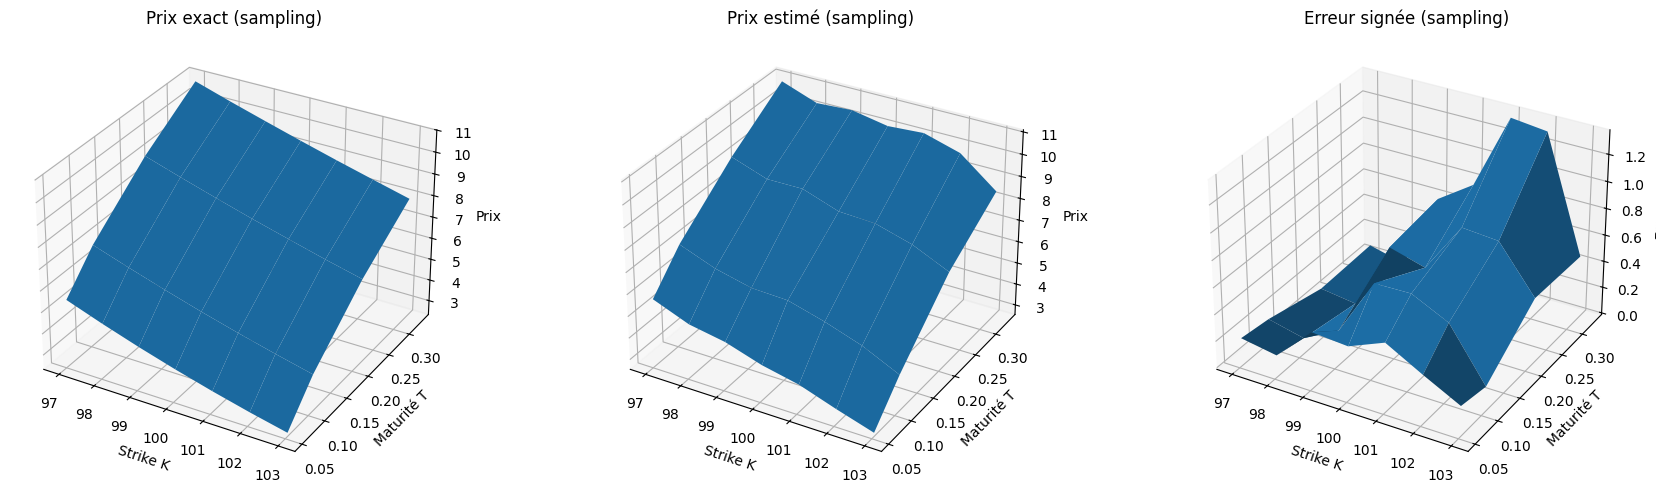

In [49]:
if __name__ == "__main__":
    res = price_european_call_quantum(
        K=100,
        T=40/365,
        S0=100,
        vol=0.4,
        r=0.05,
        num_uncertainty_qubits=6,
        c_approx=0.20,
        method="sampling",
        sampling_shots=10_000,
        seed=75,
    )

    print("Single price with sampling ")
    print("Exact:", res["exact_value"])
    print("Estimate:", res["estimate"])
    print("Error:", res["error"])
    Ks = np.arange(97, 104, 1)
    Ts = np.array([20, 40, 80, 120]) / 365

    exact, est, err = compute_surface(
        Ks=Ks,
        Ts=Ts,
        method="sampling",
        num_uncertainty_qubits=6,
        c_approx=0.20,
        sampling_shots=10_000,
        seed=75,
    )

    fig = plot_3_surfaces(Ks, Ts, exact, est, err, title_suffix="(sampling)")
    plt.show()